In [36]:
import torch
import torch.nn as nn
from collections import deque
import random
import torch.optim as optim
from ipynb.fs.defs.feature_engineering import monte_carlo_data
import pandas as pd
import numpy as np


class QNetwork(nn.Module):

    def __init__(self):

        super().__init__()
        self.fc1 = nn.Linear(6,64)
        self.fc2 = nn.Linear(64,64)
        self.fc3 = nn.Linear(64,5)

    def forward(self,z):
        x = self.fc1(z)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)

        return x


class ReplayBuffer():

    def __init__(self,capacity):
        self.memory = deque(maxlen=capacity)

    def push(self,transition):
        self.memory.append(transition)

    def sample(self,batch_size):
        return random.sample(self.memory,batch_size)

    def __len__(self):
        return len(self.memory)

class DQNAgent:

    def __init__(
        self,
        gamma=0.99,
        batch_size=32,
        epsilon=1.0,
        epsilon_decay=0.99,
        epsilon_min=0.01,
        buffer_size=10000,
        learning_rate=0.001
    ):

        self.policy_net = QNetwork()
        self.target_net = QNetwork()

        self.target_net.load_state_dict(
            self.policy_net.state_dict()
        )

        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=learning_rate
        )

        self.replay_buffer = ReplayBuffer(
            buffer_size
        )

        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

    def choose_action(self, state):

        position_fraction = state[5]

        valid_actions = [0, 1, 2, 3, 4]

        if position_fraction <= 0:

            valid_actions.remove(3)
            valid_actions.remove(4)

        elif position_fraction >= 0.99:

            valid_actions.remove(1)
            valid_actions.remove(2)

        if random.random() < self.epsilon:

            return random.choice(valid_actions)

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():

            q_values = (
                self.policy_net(state_tensor)
                .squeeze()
            )

        best_action = valid_actions[0]
        best_q = q_values[best_action]

        for action in valid_actions:

            if q_values[action] > best_q:

                best_q = q_values[action]
                best_action = action

        return best_action

    def train_step(self):

        if len(self.replay_buffer) < self.batch_size:
            return

        transitions = self.replay_buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)

        states = torch.tensor(states,dtype=torch.float32)

        actions = torch.tensor(
            actions,dtype=torch.long).unsqueeze(1)
        rewards = torch.tensor(rewards,dtype=torch.float32)

        next_states = torch.tensor(
            next_states,
            dtype=torch.float32
        )

        dones = torch.tensor(
            dones,
            dtype=torch.float32
        )

        q_values = self.policy_net(states)

        current_q = q_values.gather(
            1,
            actions
        )

        with torch.no_grad():

            next_q_values = self.target_net(
                next_states
            )

            for i in range(len(next_states)):

                position_fraction = (next_states[i][5])

                if position_fraction <= 0:

                    next_q_values[i,3] = float("-inf")
                    next_q_values[i,4] = float("-inf")

                elif position_fraction >= 0.99:

                    next_q_values[i,1] = float("-inf")
                    next_q_values[i,2] = float("-inf")

            best_future_q = (
                next_q_values
                .max(dim=1)
                .values
            )

            target_q = (
                rewards
                + (1 - dones)
                * self.gamma
                * best_future_q
            )

        target_q = target_q.unsqueeze(1)

        loss = nn.MSELoss()(
            current_q,
            target_q
        )

        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

    def update_target_net(self):

        self.target_net.load_state_dict(
            self.policy_net.state_dict()
        )
        
   


In [37]:
class TradingEnv:

    def __init__(self, feature_df, initial_cash=10000):

        self.data = feature_df
        self.prices = feature_df["price"]

        self.initial_cash = initial_cash
        self.current_step = 0

        self.cash = initial_cash
        self.shares_held = 0
        self.portfolio_value = initial_cash

        self.transaction_cost = 0.001
        self.entry_price = None

        self.valid_buys = 0
        self.invalid_buys = 0

        self.trade_profits = []

    def reset(self):

        self.current_step = 0
        self.cash = self.initial_cash
        self.shares_held = 0
        self.portfolio_value = self.initial_cash
        self.entry_price = None
        self.trade_profits = []

        return self.get_state()

    def get_state(self):

        row = self.data.iloc[self.current_step]

        momentum = row["momentum"]
        volatility = row["volatility"]
        ma_signal = row["ma_signal"]
        rsi = row["rsi"]

        current_price = self.prices.iloc[self.current_step]

        if self.entry_price is None:
            unrealized_pnl = 0.0
        else:
            unrealized_pnl = (
                current_price - self.entry_price
            ) / self.entry_price

        if self.portfolio_value > 0:
            position_fraction = (
                self.shares_held * current_price
            ) / self.portfolio_value
        else:
            position_fraction = 0.0

        return [
            momentum,
            volatility,
            ma_signal,
            rsi,
            unrealized_pnl,
            position_fraction
        ]

    def step(self, action):

        current_price = self.prices.iloc[self.current_step]

        reward_penalty = 0
        reward_bonus = 0

        old_portfolio_value = self.portfolio_value

        if action == 1:

            fraction = 0.5

            if self.cash >= current_price:

                amount_invest = self.cash * fraction

                shares_to_buy = (
                    amount_invest / current_price
                )

                fee = (
                    amount_invest
                    * self.transaction_cost
                )

                self.cash -= (
                    amount_invest + fee
                )

                self.shares_held += shares_to_buy

                if self.entry_price is None:
                    self.entry_price = current_price

            else:

                reward_penalty = -0.001

        elif action == 2:

            fraction = 1.0

            if self.cash >= current_price:

                amount_invest = self.cash * fraction

                shares_to_buy = (
                    amount_invest / current_price
                )

                fee = (
                    amount_invest
                    * self.transaction_cost
                )

                self.cash -= (
                    amount_invest + fee
                )

                self.shares_held += shares_to_buy

                if self.entry_price is None:
                    self.entry_price = current_price

            else:

                reward_penalty = -0.001

        elif action == 3:

            fraction = 0.5

            if self.shares_held > 0:

                shares_to_sell = (
                    self.shares_held * fraction
                )

                sale_val = (
                    shares_to_sell
                    * current_price
                )

                fee = (
                    sale_val
                    * self.transaction_cost
                )

                self.cash += (
                    sale_val - fee
                )

                profit_pct = (
                    current_price
                    - self.entry_price
                ) / self.entry_price

                reward_bonus = (
                    profit_pct * 10
                )

                self.trade_profits.append(
                    profit_pct
                )

                self.shares_held -= shares_to_sell

                if self.shares_held <= 1e-8:

                    self.shares_held = 0
                    self.entry_price = None

            else:

                reward_penalty = -0.005

        elif action == 4:

            fraction = 1.0

            if self.shares_held > 0:

                shares_to_sell = (
                    self.shares_held * fraction
                )

                sale_val = (
                    shares_to_sell
                    * current_price
                )

                fee = (
                    sale_val
                    * self.transaction_cost
                )

                self.cash += (
                    sale_val - fee
                )

                profit_pct = (
                    current_price
                    - self.entry_price
                ) / self.entry_price

                reward_bonus = (
                    profit_pct 
                )

                self.trade_profits.append(
                    profit_pct
                )

                self.shares_held -= shares_to_sell

                if self.shares_held <= 1e-8:

                    self.shares_held = 0
                    self.entry_price = None

            else:

                reward_penalty = -0.005

        self.current_step += 1

        done = (
            self.current_step
            >= len(self.prices) - 1
        )

        new_price = self.prices.iloc[
            self.current_step
        ]

        self.portfolio_value = (
            self.cash
            + self.shares_held * new_price
        )

        reward = self.portfolio_value
            

        #reward += reward_penalty
        #reward += reward_bonus

        next_state = self.get_state()

        return next_state, reward, done

In [38]:
#train_prices = monte_carlo_data("MSFT ","2020-01-01", "2024-01-01").squeeze()

#env = TradingEnv(train_prices)
agent = DQNAgent()

stocks = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "META"
]
reward_history = []
price_cache = {}

for ticker in stocks:
    price_cache[ticker] = monte_carlo_data(ticker,"2020-01-01","2024-01-01").squeeze()

feature_cache = {}

for ticker in stocks:

    prices = price_cache[ticker]

    df = pd.DataFrame(index=prices.index)

    # Price
    df["price"] = prices

    # Momentum (1-day return)
    df["momentum"] = prices.pct_change()

    # Volatility (10-day rolling std of returns)
    df["volatility"] = (
        prices.pct_change()
        .rolling(10)
        .std()
    )

    # MA Signal
    ma20 = prices.rolling(20).mean()
    df["ma_signal"] = (
        prices - ma20
    ) / ma20

    # RSI
    delta = prices.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(14).mean()
    avg_loss = losses.rolling(14).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    df["rsi"] = rsi / 100.0

    # Fill early NaNs
    df = df.fillna(0)

    feature_cache[ticker] = df

for episode in range(400):
    
    ticker = random.choice(stocks)
    prices = price_cache[ticker]

    env = TradingEnv(feature_cache[ticker])
    state = env.reset()
    done = False
    episode_reward = 0
    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)
        episode_reward += reward
        
        agent.replay_buffer.push(
            (state, action, reward, next_state, done)
        )

        agent.train_step()

        state = next_state
    reward_history.append(episode_reward) 
    agent.epsilon = max(agent.epsilon_min,agent.epsilon * agent.epsilon_decay)

    agent.update_target_net()
    print(
        f"Episode {episode+1} | "
        f"Reward: {episode_reward:.4f} | "
        f"Epsilon: {agent.epsilon:.4f}"
    )


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Episode 1 | Reward: 9227535.3565 | Epsilon: 0.9900
Episode 2 | Reward: 9419884.7164 | Epsilon: 0.9801
Episode 3 | Reward: 8491223.1720 | Epsilon: 0.9703
Episode 4 | Reward: 8055924.1541 | Epsilon: 0.9606
Episode 5 | Reward: 11947251.0334 | Epsilon: 0.9510
Episode 6 | Reward: 13953687.8956 | Epsilon: 0.9415
Episode 7 | Reward: 9040507.3978 | Epsilon: 0.9321
Episode 8 | Reward: 11795314.5112 | Epsilon: 0.9227
Episode 9 | Reward: 9930720.4253 | Epsilon: 0.9135
Episode 10 | Reward: 8498630.9304 | Epsilon: 0.9044
Episode 11 | Reward: 12024157.7160 | Epsilon: 0.8953
Episode 12 | Reward: 9705998.5658 | Epsilon: 0.8864
Episode 13 | Reward: 11311080.0842 | Epsilon: 0.8775
Episode 14 | Reward: 12246879.6564 | Epsilon: 0.8687
Episode 15 | Reward: 10348000.5190 | Epsilon: 0.8601
Episode 16 | Reward: 13644237.9447 | Epsilon: 0.8515
Episode 17 | Reward: 7117137.4499 | Epsilon: 0.8429
Episode 18 | Reward: 8476291.5470 | Epsilon: 0.8345
Episode 19 | Reward: 8149416.5313 | Epsilon: 0.8262
Episode 20 | 

In [44]:
def evaluate_agent(agent, feature_df):

    env = TradingEnv(feature_df)

    state = env.reset()
    done = False

    portfolio_values = []
    actions_taken = []

    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)

        portfolio_values.append(env.portfolio_value)
        actions_taken.append(action)

        state = next_state

    final_value = env.portfolio_value

    total_return = (
        final_value - env.initial_cash
    ) / env.initial_cash

    prices = feature_df["price"]

    buy_hold_return = (
        prices.iloc[-1] - prices.iloc[0]
    ) / prices.iloc[0]

    num_buys = (
        actions_taken.count(1)
        + actions_taken.count(2)
    )

    num_sells = (
        actions_taken.count(3)
        + actions_taken.count(4)
    )

    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Strategy Return: {total_return*100:.2f}%")
    print(f"Buy & Hold Return: {buy_hold_return*100:.2f}%")
    print(f"Buys: {num_buys}")
    print(f"Sells: {num_sells}")

    profits = env.trade_profits

    wins = [p for p in profits if p > 0]
    losses = [p for p in profits if p <= 0]

    if len(profits) == 0:

        win_rate = 0
        avg_win = 0
        avg_loss = 0
        profit_factor = 0
        

    else:

        win_rate = len(wins) / len(profits)

        avg_win = (
            sum(wins) / len(wins)
            if wins else 0
        )

        avg_loss = (
            sum(losses) / len(losses)
            if losses else 0
        )

        profit_factor = (
            sum(wins) / abs(sum(losses))
            if losses else float("inf")
        )

        portfolio_values = np.array(portfolio_values)

        returns = (
            portfolio_values[1:]
            - portfolio_values[:-1]
        ) / portfolio_values[:-1]
        
        if len(returns) > 0 and returns.std() > 0:
            sharpe = (
                returns.mean()
                / returns.std()
            ) * np.sqrt(252)
        else:
            sharpe = 0
        
        running_max = np.maximum.accumulate(
            portfolio_values
        )
        
        drawdowns = (
            portfolio_values - running_max
        ) / running_max
        
        max_drawdown = drawdowns.min()

        print("Win Rate:", win_rate)
        print("Average Win:", avg_win)
        print("Average Loss:", avg_loss)
        print("Profit Factor:", profit_factor)
        print("Sharpe Ratio:", sharpe)
        print(
            "Max Drawdown:",
            f"{max_drawdown*100:.2f}%"
        )

    return {
    "final_value": final_value,
    "strategy_return": total_return,
    "buy_hold_return": buy_hold_return,
    "portfolio_values": portfolio_values,
    "actions": actions_taken,
    "sharpe": sharpe,
    "max_drawdown": max_drawdown
}

In [40]:
print(Counter(results["actions"]))

NameError: name 'Counter' is not defined

In [45]:
test_stocks = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "META"
]

results_table = []

for ticker in test_stocks:

    prices = monte_carlo_data(
        ticker,
        "2024-01-01",
        "2025-01-01"
    ).squeeze()

    df = pd.DataFrame(index=prices.index)

    df["price"] = prices
    df["momentum"] = prices.pct_change()
    df["volatility"] = prices.pct_change().rolling(10).std()

    ma20 = prices.rolling(20).mean()

    df["ma_signal"] = (
        prices - ma20
    ) / ma20

    delta = prices.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(14).mean()
    avg_loss = losses.rolling(14).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    df["rsi"] = rsi / 100.0

    df = df.fillna(0)

    res = evaluate_agent(agent, df)

    results_table.append({
        "ticker": ticker,
        "strategy": res["strategy_return"],
        "buyhold": res["buy_hold_return"]
    })

for row in results_table:
    print(row)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Final Portfolio Value: $12934.38
Strategy Return: 29.34%
Buy & Hold Return: 35.56%
Buys: 1
Sells: 1
Win Rate: 1.0
Average Win: 0.2957334421590067
Average Loss: 0
Profit Factor: inf
Sharpe Ratio: 1.5591970087261184
Max Drawdown: -11.76%
Final Portfolio Value: $11234.83
Strategy Return: 12.35%
Buy & Hold Return: 14.50%
Buys: 3
Sells: 1
Win Rate: 1.0
Average Win: 0.10502616178020738
Average Loss: 0
Profit Factor: inf
Sharpe Ratio: 1.0710839983287193
Max Drawdown: -7.26%
Final Portfolio Value: $10473.02
Strategy Return: 4.73%
Buy & Hold Return: 36.95%
Buys: 3
Sells: 2
Win Rate: 0.5
Average Win: 0.021853133620358314
Average Loss: -0.025659873874917746
Profit Factor: 0.8516461821630199
Sharpe Ratio: 0.5294360067197228
Max Drawdown: -9.85%
Final Portfolio Value: $11058.54
Strategy Return: 10.59%
Buy & Hold Return: 46.33%
Buys: 1
Sells: 1
Win Rate: 0.0
Average Win: 0
Average Loss: -0.00528275003374956
Profit Factor: 0.0
Sharpe Ratio: 0.6077825186408669
Max Drawdown: -19.51%
Final Portfolio Val

In [ ]:
for stock in results_table:
    print(stock)
    

In [46]:
import matplotlib.pyplot as plt
all_curves = []

for ticker in test_stocks:

    res = evaluate_agent(agent, prices)

    all_curves.append(
        np.array(res["portfolio_values"])
    )

avg_curve = np.mean(all_curves, axis=0)

plt.figure(figsize=(10,5))
plt.plot(avg_curve)
plt.title("Average Portfolio Value")
plt.show()

KeyError: 'price'

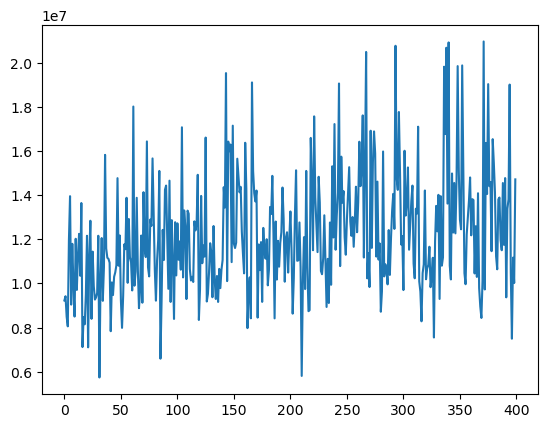

In [47]:
plt.plot(reward_history)
plt.show()

In [ ]:
print(env.valid_buys)
print(env.invalid_buys)